# St. Helens analysis (clean)

This notebook generates three initial plots from the `results/sthelens` artifacts:
1) VolcanoFigure map + cross-sections (NLL located catalog)
2) Events per day time series
3) HSR helicorder for one day with EQT detections + EQT picks + NLL located picks overlays


In [11]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from obspy import UTCDateTime
from obspy.imaging.util import _set_xaxis_obspy_dates

# Make analysis_local/utils importable without requiring wav2hyp package init
cwd = Path.cwd()
if (cwd / "utils" / "sthelens_nb_utils.py").exists():
    utils_dir = cwd / "utils"
elif (cwd / "analysis_local" / "utils" / "sthelens_nb_utils.py").exists():
    utils_dir = cwd / "analysis_local" / "utils"
else:
    # Fallback: assume notebook executed from repo root
    utils_dir = cwd / "analysis_local" / "utils"

sys.path.insert(0, str(utils_dir))
# Ensure vdapseisutils is importable (it lives in ../vdapseisutils)
sys.path.insert(0, "/home/jwellik/PYTHON/PKG/vdapseisutils")
from sthelens_nb_utils import (
    load_yaml,
    infer_repo_root,
    sthelens_paths,
    load_nll_catalog_from_catalog_table,
    load_eqt_picks_and_detections,
    filter_eqt_for_station_phase,
    detections_intervals_for_station,
    located_pick_times_from_nll_quakeml,
    load_hr_stream_from_sds,
    HelicoorderStyle,
)

from vdapseisutils import VolcanoFigure
from vdapseisutils.core.swarmmpl.heli import Helicorder


In [12]:
# ----------------------------
# Configuration
# ----------------------------
repo_root = infer_repo_root()

# Prefer the SDS-backed config (so helicorder can actually fetch waveforms)
cfg = load_yaml("/home/jwellik/PYTHON/PKG/wav2hyp/examples_local/sthelens.yaml")

NETWORK = "UW"
STATION = "HSR"

target_lat = float(cfg["target"]["latitude"])
target_lon = float(cfg["target"]["longitude"])
origin = (target_lat, target_lon)

# Plot width/extent from sthelens.yaml
radial_extent_km = float(cfg["associator"]["radius_km"])
depth_limits_km = cfg["associator"]["depth_limits"]  # [min_km, max_km] (min can be negative above sea)
# VolcanoFigure expects depth extent in the sign convention used by its cross-section plotting.
# With depth_km positive down in catalog_table, prep_catalog_data_mpl flips sign for plotting.
# For now, force the cross-section y-axis limits.
# VolcanoFigure passes this directly to the cross-section axis as `set_ylim`.
depth_extent_km_plot = (-15.0, 5.0)

base_results_dir = Path("/home/jwellik/PYTHON/PKG/wav2hyp/results/sthelens")
paths = sthelens_paths(base_results_dir=base_results_dir)
nll_h5 = paths["nll_h5"]
eqt_h5 = paths["eqt_picks_h5_alt"] if (paths["eqt_picks_h5_alt"]).exists() else paths["eqt_picks_h5"]

# NLL located catalog covers processing days 2004/09/23 and 2004/09/24
NLL_T1 = "2004-09-23"
NLL_T2 = "2004-09-25"  # exclusive-ish upper bound for convenience in filtering

# Helicoorder: one UTC day
HELICORDER_DAY = "2004-09-24"
t1_day = UTCDateTime(f"{HELICORDER_DAY}T00:00:00")
t2_day = t1_day + 86400

out_dir = Path(paths["output_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

print("origin", origin)
print("radial_extent_km", radial_extent_km)
print("depth_extent_km_plot", depth_extent_km_plot)
print("nll_h5", nll_h5)
print("eqt_h5", eqt_h5)


origin (46.2, -122.18)
radial_extent_km 250.0
depth_extent_km_plot (-15.0, 5.0)
nll_h5 /home/jwellik/PYTHON/PKG/wav2hyp/results/sthelens/3_locations/nll.h5
eqt_h5 /home/jwellik/PYTHON/PKG/wav2hyp/results/sthelens/1_picks/eqt-volpick.h5


In [13]:
# ----------------------------
# 1) Map + cross section (NLL located catalog)
# ----------------------------
cat_nll = load_nll_catalog_from_catalog_table(nll_h5, t1=NLL_T1, t2=NLL_T2)

fig = VolcanoFigure(
    origin=origin,
    radial_extent_km=radial_extent_km,
    depth_extent=depth_extent_km_plot,
)

# Background map
try:
    # Terrain tiles (ArcGIS by default)
    fig.add_terrain()
except Exception as e:
    print("Terrain tiles failed:", e)

try:
    # Hillshade overlay (falls back gracefully if PyGMT isn't available)
    fig.add_hillshade(alpha=0.7)
except Exception as e:
    print("Hillshade failed:", e)

# mag is often missing in catalog_table; pass a constant marker size.
fig.plot_catalog(cat_nll, s=10, c="purple", alpha=0.7)

png = out_dir / "sthelens_map_xs_nll_catalog.png"
fig.savefig(str(png), dpi=300)
print("Saved", png)


/home/jwellik/miniconda3/envs/vseis312/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))
/home/jwellik/miniconda3/envs/vseis312/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))
ERROR 4: `/home/jwellik/.gmt/server/earth/earth_relief/earth_relief_30s_g/N30W135.earth_relief_30s_g.jp2' not recognized as being in a supported file format. It could have been recognized by driver JP2OpenJPEG, but plugin gdal_JP2OpenJPEG.so is not available in your installation. You may install it with 'conda install -c conda-forge libgdal-jp2openjpeg'
ERROR 4: `/home/jwellik/.gmt/server/earth/earth_re

Auto-selected resolution: 30s
Failed to load hillshade data: NULL pointer access


/home/jwellik/miniconda3/envs/vseis312/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/jwellik/PYTHON/PKG/vdapseisutils/vdapseisutils/core/maps/maps.py:1521: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = self.ax.scatter(x, catdata["depth"], s=s, c=c, cmap=cmap, alpha=alpha, **kwargs)
/home/jwellik/PYTHON/PKG/vdapseisutils/vdapseisutils/core/maps/maps.py:1521: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = self.ax.scatter(x, catdata["depth"], s=s, c=c, cmap=cmap, alpha=alpha, **kwargs)


Saved /home/jwellik/PYTHON/PKG/wav2hyp/analysis_local/sthelens_map_xs_nll_catalog.png


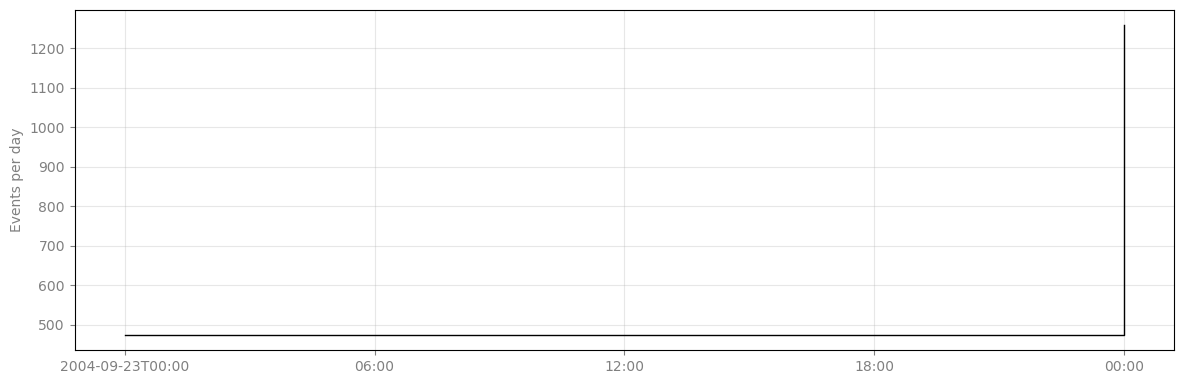

Saved /home/jwellik/PYTHON/PKG/wav2hyp/analysis_local/sthelens_events_per_day.png


In [14]:
# ----------------------------
# 2) Events per day
# ----------------------------
cat_df = pd.read_hdf(nll_h5, key="catalog_table")
cat_df = cat_df[(cat_df["origin_time"] >= pd.Timestamp(NLL_T1, tz="UTC")) & (cat_df["origin_time"] <= pd.Timestamp(NLL_T2, tz="UTC"))]
times = pd.to_datetime(cat_df["origin_time"])
series = pd.Series(1, index=times)
counts = series.resample("1D").count()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.step(counts.index, counts.values, where="post", color="black")
_set_xaxis_obspy_dates(ax)
ax.set_ylabel("Events per day")
ax.grid(True, alpha=0.3)
plt.tight_layout()

png = out_dir / "sthelens_events_per_day.png"
fig.savefig(str(png), dpi=300)
plt.show()
print("Saved", png)


In [15]:
# # ----------------------------
# # 3) HSR helicorder + overlays (detections + picks + located picks)
# # ----------------------------
# style = HelicoorderStyle()

# # Waveforms for helicorder
# st = load_hr_stream_from_sds(
#     datasource_root=cfg["waveform_client"]["datasource"],
#     network=NETWORK,
#     station=STATION,
#     starttime=t1_day,
#     endtime=t2_day,
# )

# heli = Helicorder(
#     st,
#     figsize=(12, 12),
#     title=f"{STATION} helicorder ({HELICORDER_DAY})",
# )

# # EQT detections + picks
# picks_df, detections_df = load_eqt_picks_and_detections(eqt_h5, t1=t1_day, t2=t2_day)

# # Detections highlighted as a yellow time span
# det_intervals = detections_intervals_for_station(
#     detections_df,
#     network=NETWORK,
#     station=STATION,
# )
# heli.highlight(det_intervals, color="yellow", alpha=0.25)

# # All picks (EQT)
# p_times_all = filter_eqt_for_station_phase(picks_df, NETWORK, STATION, phase="P")
# s_times_all = filter_eqt_for_station_phase(picks_df, NETWORK, STATION, phase="S")

# heli.plot_tags(
#     p_times_all,
#     marker="o",
#     color=style.all_p_color,
#     markeredgecolor=style.all_p_edge,
#     markersize=style.marker_size,
# )
# heli.plot_tags(
#     s_times_all,
#     marker="o",
#     color=style.all_s_color,
#     markeredgecolor=style.all_s_edge,
#     markersize=style.marker_size,
# )

# # Located picks (NLL located QuakeML)
# p_times_loc = located_pick_times_from_nll_quakeml(nll_h5, STATION, phase="P", t1=t1_day, t2=t2_day)
# s_times_loc = located_pick_times_from_nll_quakeml(nll_h5, STATION, phase="S", t1=t1_day, t2=t2_day)

# # Located P: red fill with blue outline
# heli.plot_tags(
#     p_times_loc,
#     marker="o",
#     color=style.located_p_color,
#     markeredgecolor=style.located_p_edge,
#     markersize=style.located_marker_size,
# )
# # Located S: blue fill with red outline
# heli.plot_tags(
#     s_times_loc,
#     marker="o",
#     color=style.located_s_color,
#     markeredgecolor=style.located_s_edge,
#     markersize=style.located_marker_size,
# )

# png = out_dir / f"sthelens_helicorder_{STATION}_{HELICORDER_DAY}.png"
# heli.savefig(str(png), dpi=200)
# plt.show()
# print("Saved", png)
